In [2]:
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt
from adjustText import adjust_text

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


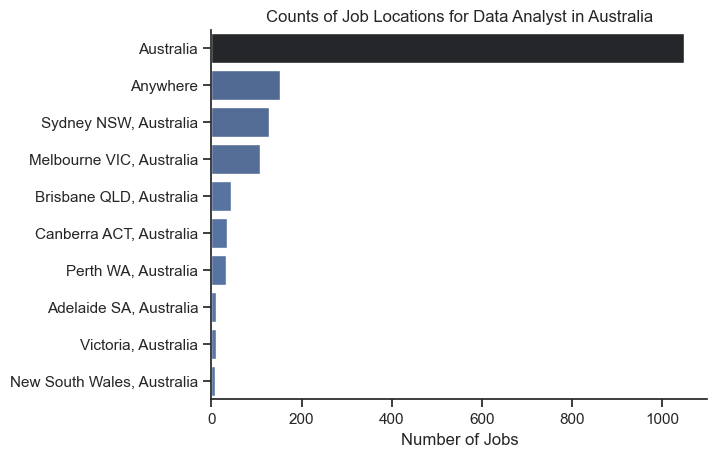

job_health_insurance
False    1658
Name: count, dtype: int64

In [ ]:
df_DA_AUZ = df[(df['job_country'] == 'Australia') & (df['job_title_short'] == 'Data Analyst')]
df_plot = df_DA_AUZ['job_location'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Counts of Job Locations for Data Analyst in Australia')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

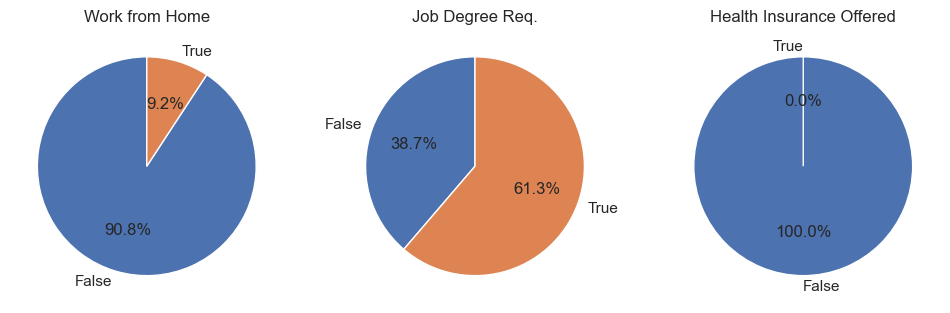

In [21]:
dict_column = {
  "job_work_from_home": 'Work from Home',
  "job_no_degree_mention": 'Job Degree Req.',
  "job_health_insurance": 'Health Insurance Offered'
}

fig, ax = plt.subplots(1, 3)
fig.set_size_inches((12, 5))

for i, (column, title) in enumerate(dict_column.items()):
    counts = df_DA_AUZ[column].value_counts().reindex([False, True], fill_value=0)

    ax[i].pie(
        counts,
        labels=['False', 'True'],
        startangle=90,
        autopct='%1.1f%%'
    )
    ax[i].set_title(title)

plt.show()

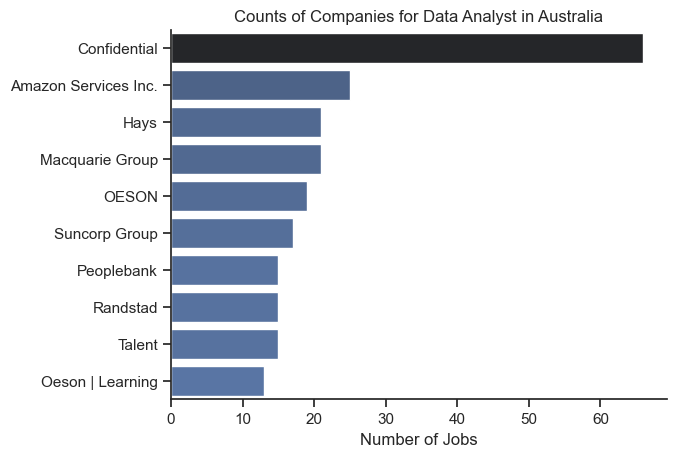

In [24]:
df_plot = df_DA_AUZ['company_name'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Counts of Companies for Data Analyst in Australia')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()